# 당뇨병

In [102]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [103]:
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [104]:
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [105]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [106]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [107]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [108]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [109]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [110]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [111]:
LEARNING_RATE = 0.001

In [112]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 1001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 21751.1403
Iteration 200 : Loss 16562.5353
Iteration 300 : Loss 13083.3388
Iteration 400 : Loss 10749.5361
Iteration 500 : Loss 9183.2103
Iteration 600 : Loss 8131.1389
Iteration 700 : Loss 7423.6507
Iteration 800 : Loss 6947.0578
Iteration 900 : Loss 6625.1838
Iteration 1000 : Loss 6406.9870
132 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


---------------------------

In [160]:
data = load_diabetes()
np_X = data.data
np_y = data.target

print(type(np_X), type(np_y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [161]:
print(type(data), data.feature_names, type(data.feature_names))
# 출력: ('id', 'value', 'label')


<class 'sklearn.utils._bunch.Bunch'> ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'] <class 'list'>


In [162]:
import pandas as pd
df_X = pd.DataFrame(data.data, columns=data.feature_names)
df_y = pd.DataFrame(data.target) 

In [163]:
df_X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


# 결측치 없음

In [164]:
df_X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [165]:
df_X.isna().sum()

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

# 데이터 컬럼 확인

In [166]:
df_X.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

# 데이터 분포 확인
- 데이터 분포 확인
- 그래프 출력에 약간 대기

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

# fig, axes = plt.subplots(10, 1)
# # 현재 활성화된 figure 가져오기
# fig = plt.gcf()
 
# # 크기를 18.5 x 10.5 인치로 변경
# fig.set_size_inches(10, 10)

# for i in range(len(df_X.columns)):
#     df_X.iloc[:,i].plot(kind='bar', ax=axes[i], color='blue', alpha=1)
# plt.show()

# 이상치 

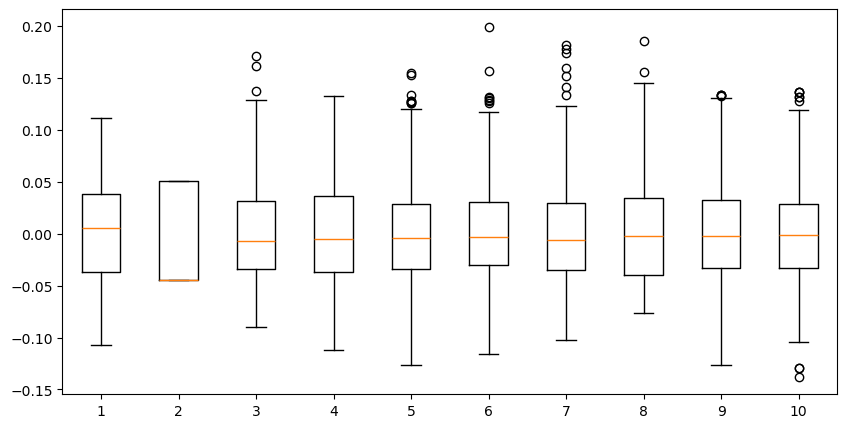

In [277]:
data = load_diabetes()
np_X = data.data
np_y = data.target

df_X = pd.DataFrame(data.data, columns=data.feature_names)
df_y = pd.DataFrame(data.target) 

fig, axes = plt.subplots()
# 현재 활성화된 figure 가져오기
fig = plt.gcf()
# 크기를 18.5 x 10.5 인치로 변경
fig.set_size_inches(10, 5)
axes.boxplot(df_X)
plt.show()

In [278]:
# Q. 사분위 범위수를 이용해서 이상치를 찾는 outlier2() 함수를 구현해보세요.
def outlier(df, col, z):
    return df[abs(df[col] - np.mean(df[col]))/np.std(df[col])>z]
    

def outlier2(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]

def outlier2_up(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] > Q3 + 1.5 * IQR)]

def outlier2_low(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] < Q1 - 1.5 * IQR)]
    
out_index_all = set()
out_index_intersection = set()

for i in df_X.columns:
    outliers = outlier(df_X, i, 1.8)
    out_index_all = out_index_all.union(set(outliers.index))
    # out_index_intersection = out_index_all.intersection(set(outliers.index))
    print(i, len(outliers), outliers.index)

# for i in df_X.columns:
#     outliers = outlier2_up(df_X, i)
#     # print(df_X.loc[outliers.index, i])
#     df_X.loc[outliers.index, i] = df_X[i].quantile(0.75)
#     outliers = outlier2_low(df_X, i)
#     # print(df_X.loc[outliers.index, i])
#     df_X.loc[outliers.index, i] = df_X[i].quantile(0.25)
#     # print(df_X.loc[outliers.index, i])

# for i in df_X.columns:
#     outliers = outlier2(df_X, i)
#     out_index_all = out_index_all.union(set(outliers.index))
#     print(i, len(outliers), outliers.index)

print('index_all', 'len', len(df_X))    
print('out_index_all', out_index_all, 'len', len(out_index_all))    

age 25 Index([  3,   5,  10,  26,  41,  77,  79, 102, 106, 126, 131, 136, 204, 211,
       219, 223, 226, 242, 281, 311, 318, 321, 344, 374, 402],
      dtype='int64')
sex 0 Index([], dtype='int64')
bmi 24 Index([ 32,  97, 114, 130, 138, 145, 147, 215, 251, 256, 262, 268, 281, 293,
       327, 332, 362, 366, 367, 381, 403, 405, 407, 428],
      dtype='int64')
bp 26 Index([ 38,  41,  71,  84,  92,  93, 117, 130, 137, 159, 171, 215, 217, 224,
       251, 261, 262, 303, 340, 343, 350, 375, 400, 408, 416, 428],
      dtype='int64')
s1 32 Index([  7,  10,  15,  26,  38,  57,  72,  76, 123, 161, 166, 174, 202, 230,
       242, 248, 276, 282, 287, 298, 336, 346, 349, 353, 354, 376, 379, 384,
       405, 414, 418, 425],
      dtype='int64')
s2 33 Index([  7,  10,  15,  26,  29,  33,  57,  76, 123, 155, 161, 174, 182, 202,
       230, 248, 276, 282, 286, 287, 304, 320, 336, 346, 352, 354, 376, 379,
       384, 405, 414, 418, 425],
      dtype='int64')
s3 20 Index([ 32,  33,  35,  43,  58,  82, 

In [279]:
df_X.drop(list(out_index_all), axis=0, inplace=True)
print(df_X.shape)

df_y.drop(list(out_index_all), axis=0, inplace=True)
print(df_y.shape)

(276, 10)
(276, 1)


In [280]:
# from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df_X, df_y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(220, 10) (220, 1)
(56, 10) (56, 1)


In [281]:
LEARNING_RATE = 0.08

In [282]:
# %%timeit -n 1 -r 1
X = np.array(df_X)
y = np.array(df_y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

global W, b
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

losses = []

for i in range(1, 4001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

(220, 10) (220,)
(56, 10) (56,)
10
Iteration 100 : Loss 4438.5857
Iteration 200 : Loss 4267.8864
Iteration 300 : Loss 4117.0666
Iteration 400 : Loss 3983.4879
Iteration 500 : Loss 3864.8838
Iteration 600 : Loss 3759.3061
Iteration 700 : Loss 3665.0789
Iteration 800 : Loss 3580.7594
Iteration 900 : Loss 3505.1043
Iteration 1000 : Loss 3437.0412
Iteration 1100 : Loss 3375.6444
Iteration 1200 : Loss 3320.1136
Iteration 1300 : Loss 3269.7562
Iteration 1400 : Loss 3223.9721
Iteration 1500 : Loss 3182.2406
Iteration 1600 : Loss 3144.1092
Iteration 1700 : Loss 3109.1840
Iteration 1800 : Loss 3077.1216
Iteration 1900 : Loss 3047.6221
Iteration 2000 : Loss 3020.4231
Iteration 2100 : Loss 2995.2944
Iteration 2200 : Loss 2972.0338
Iteration 2300 : Loss 2950.4632
Iteration 2400 : Loss 2930.4255
Iteration 2500 : Loss 2911.7818
Iteration 2600 : Loss 2894.4086
Iteration 2700 : Loss 2878.1965
Iteration 2800 : Loss 2863.0478
Iteration 2900 : Loss 2848.8751
Iteration 3000 : Loss 2835.6004
Iteration 3100

# 프로젝트 2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?



In [2]:
import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [4]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

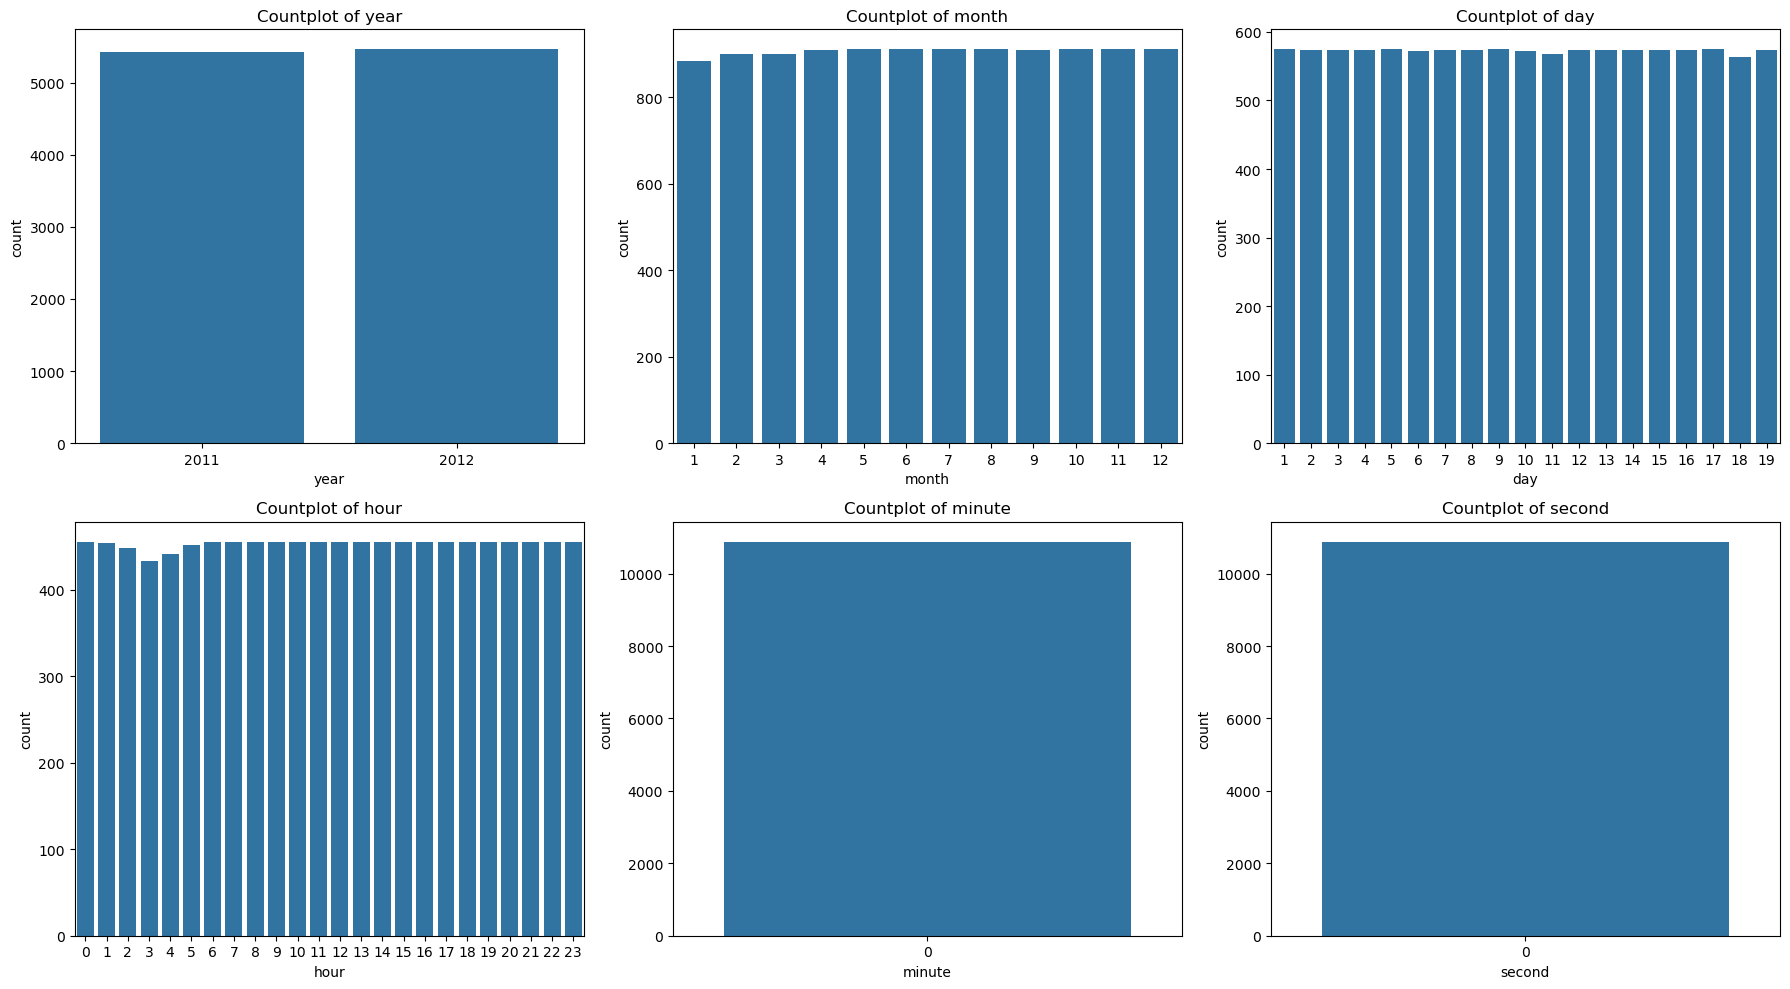

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

## 컬럼을 추가해 count를 시각화

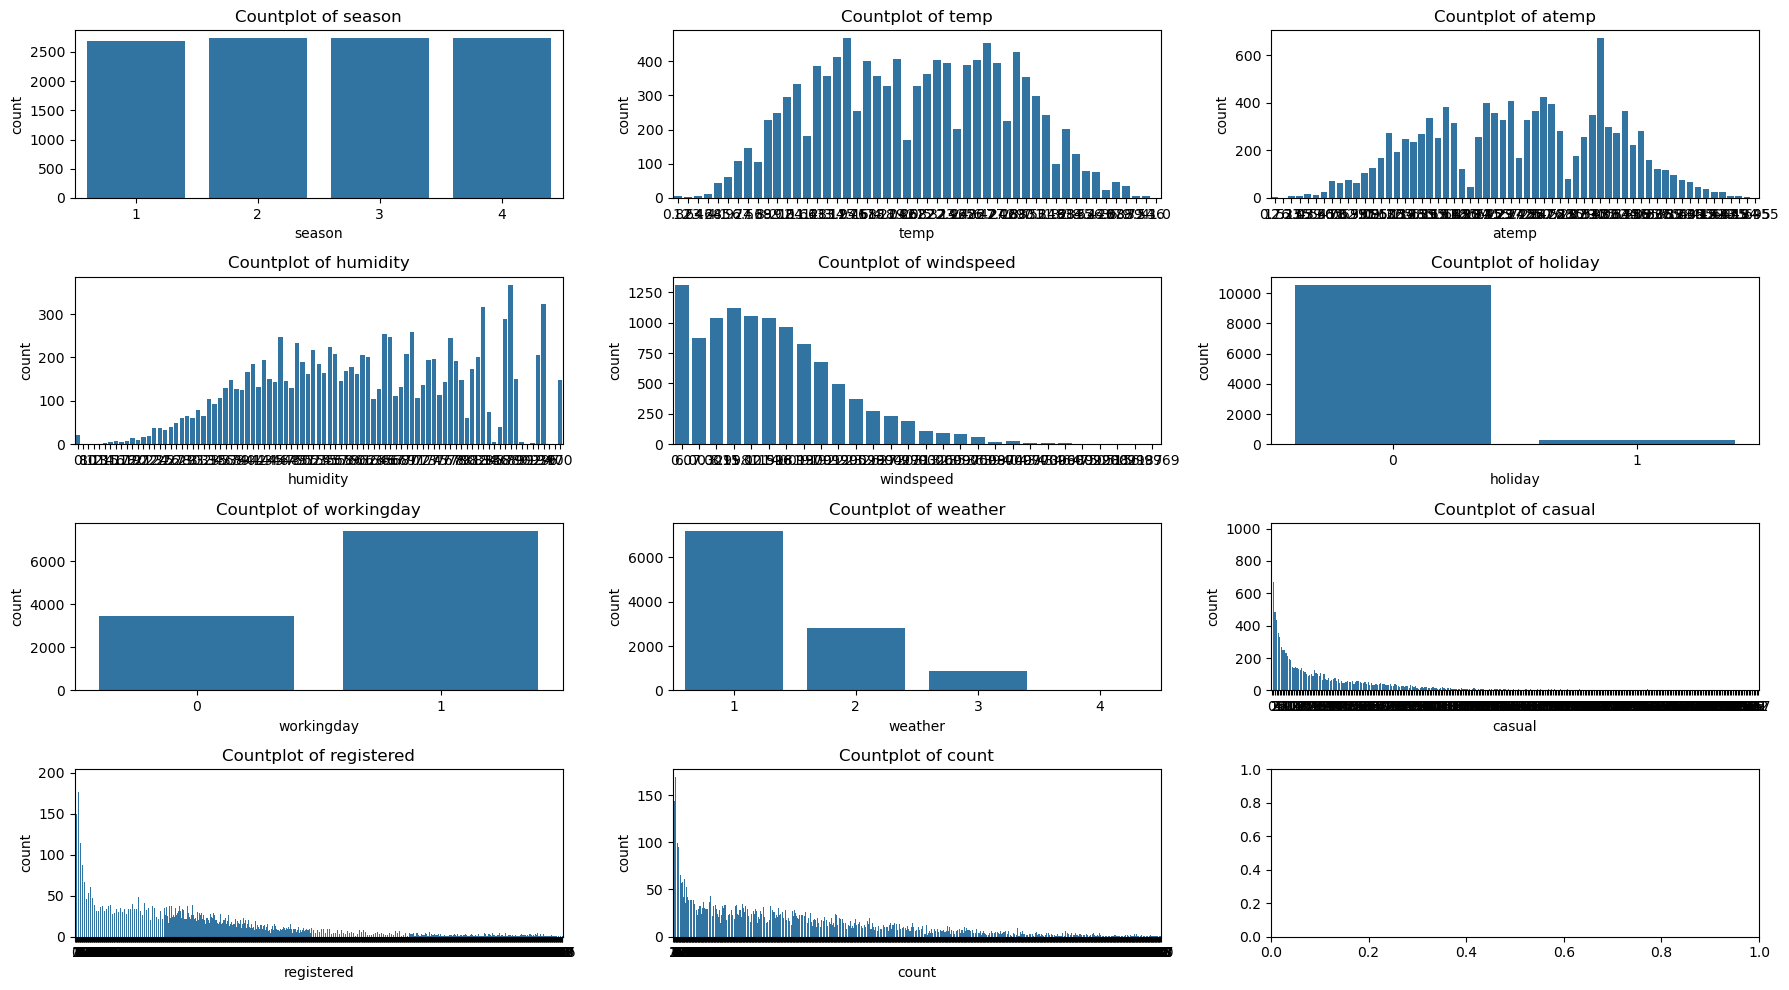

In [6]:
fig, axs = plt.subplots(4, 3, figsize=(18, 10))
cols = ['season','temp', 'atemp', 'humidity', 'windspeed', 'holiday',	'workingday',	'weather', 'casual','registered', 'count']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()

plt.show()

In [453]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,0,0


In [454]:
## 자전거 대여량 예측
- RMSE 141로 150이하임

SyntaxError: invalid syntax (1023344096.py, line 2)

MSE: 19961.901814435438
RMSE: 141.2865946027274


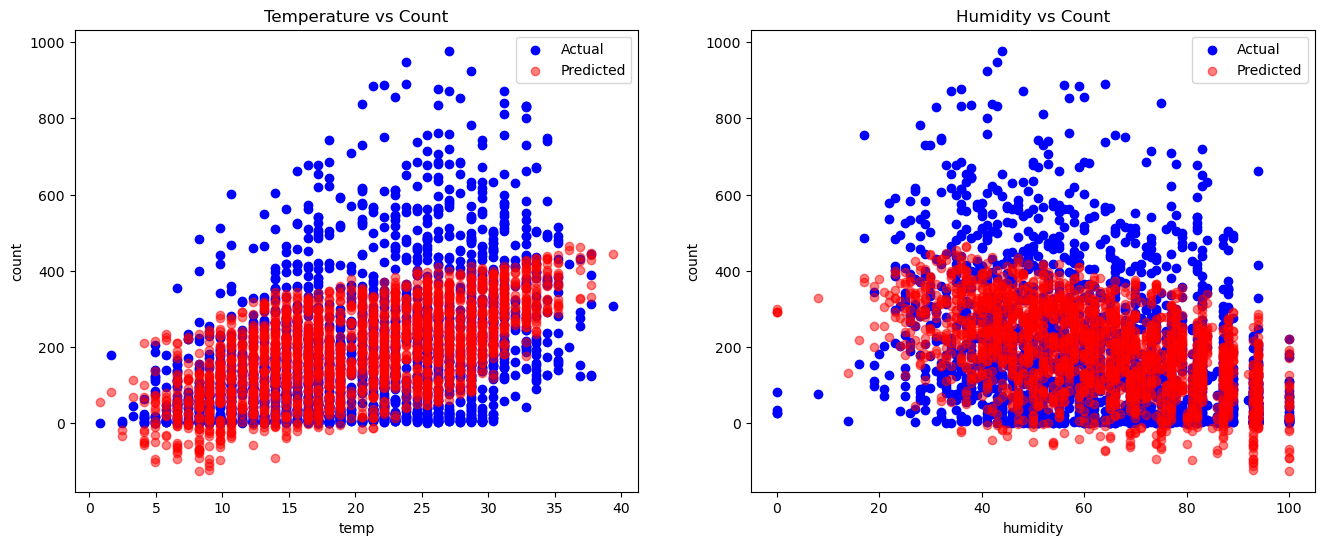

In [455]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']

X = train[features]
y = train['count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()


In [1]:
## features 항목에 컬럼 추가/삭제
- 'casual'를 추가시 RMSE가 1 정도 'casual','registered'를 추가하면 RMSE가 9 정도로 과적합 우려할 수준으로 하락
- MIN MAX Scaler도 큰 영향 없음


SyntaxError: invalid syntax (319954614.py, line 2)

In [460]:
# features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
# features = ['year','season', 'month', 'day', 'hour',  'atemp', 'humidity', 'windspeed', 'holiday',	'weather']
# features = [ 'month','hour','atemp', 'humidity', 'windspeed', 'holiday',	'weather']
features = ['year', 'month', 'day', 'hour',  'temp', 'humidity','holiday', 'windspeed', 'casual','registered']
# 
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train

,year,month,day,hour,temp,humidity,holiday,windspeed,casual,registered
2815,2011,7,6,5,27.88,83,0,6.0032,5,30
8695,2012,8,4,16,36.90,39,0,19.9995,197,253
8406,2012,7,11,15,32.80,41,0,16.9979,56,220
1543,2011,4,10,4,14.76,93,0,7.0015,3,2
4952,2011,11,19,10,13.12,45,0,16.9979,35,165
...,...,...,...,...,...,...,...,...,...,...
5734,2012,1,14,2,6.56,47,0,11.0014,6,32
5191,2011,12,10,9,11.48,61,0,19.0012,15,134
5390,2011,12,18,16,11.48,48,0,16.9979,27,207
860,2011,2,19,7,15.58,17,0,35.0008,6,16


In [ ]:
- MinMaxScaler 주석 제거 후 실행 가능

In [462]:
%%time
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_train = pd.DataFrame(data=X_train, columns = features)

X_test = scaler.transform(X_test)
X_test = pd.DataFrame(data=X_test, columns = features)

X_train


CPU times: user 13.3 ms, sys: 78 μs, total: 13.4 ms
Wall time: 13.3 ms


,year,month,day,hour,temp,humidity,holiday,windspeed,casual,registered
0,0.0,0.545455,0.277778,0.217391,0.673469,0.83,0.0,0.105325,0.013812,0.035006
1,1.0,0.636364,0.166667,0.695652,0.897959,0.39,0.0,0.350888,0.544199,0.295216
2,1.0,0.545455,0.555556,0.652174,0.795918,0.41,0.0,0.298225,0.154696,0.256709
3,0.0,0.272727,0.500000,0.173913,0.346939,0.93,0.0,0.122840,0.008287,0.002334
4,0.0,0.909091,1.000000,0.434783,0.306122,0.45,0.0,0.298225,0.096685,0.192532
...,...,...,...,...,...,...,...,...,...,...
8703,1.0,0.000000,0.722222,0.086957,0.142857,0.47,0.0,0.193018,0.016575,0.037340
8704,0.0,1.000000,0.500000,0.391304,0.265306,0.61,0.0,0.333373,0.041436,0.156359
8705,0.0,1.000000,0.944444,0.695652,0.265306,0.48,0.0,0.298225,0.074586,0.241540
8706,0.0,0.090909,1.000000,0.304348,0.367347,0.17,0.0,0.614083,0.016575,0.018670


In [463]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [464]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 2.2728218664700896e-26
RMSE: 1.507588095757621e-13


In [ ]:
## casual, registered 추가 후 RMSE가 대폭 떨어졌으나 데이터 특성이 Target인 count와 연관성이 매우 높아 과적합 우려됨
## 다른 컬럼들은 큰 영향을 보이지 않음

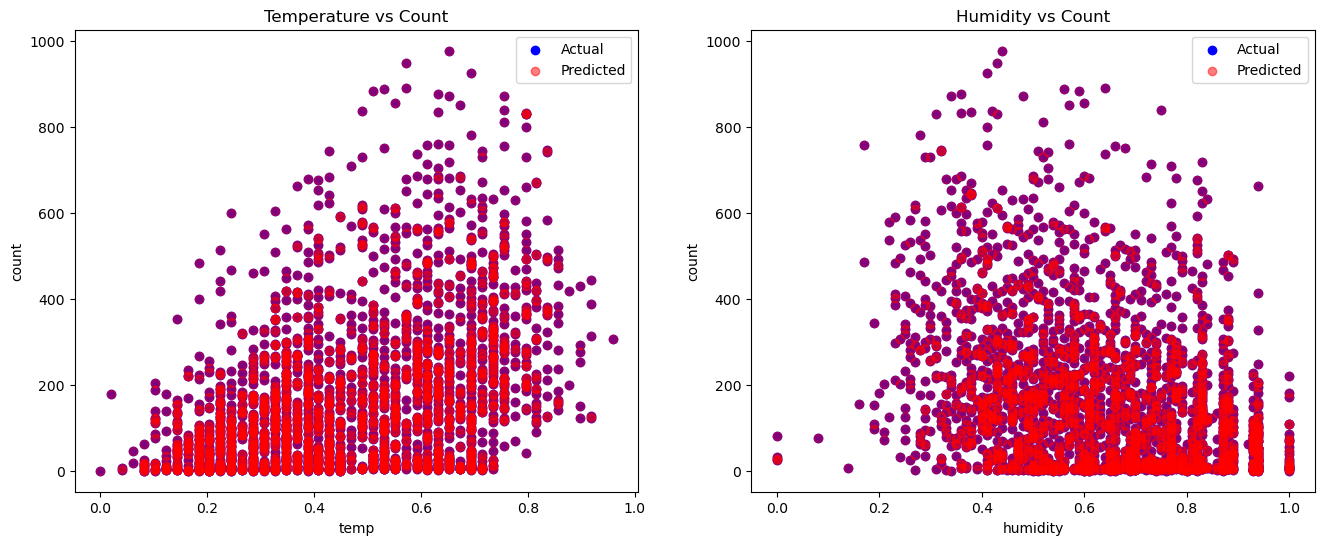

In [465]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()